# Autoencoder model

In [7]:
import os 
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from sklearn.metrics import roc_auc_score

### Dataset i DataLoader

In [5]:
dataset = 'dataset_224x224'

class MVTecDataset(Dataset):
    def __init__(self, putanja_dataseta, transformacija=None, mod="train"):
        super().__init__()
        self.transformacija = transformacija
        self.podaci = []

        kategorije = sorted([k for k in os.listdir(putanja_dataseta) if os.path.isdir(os.path.join(putanja_dataseta, k))])

        for kategorija in kategorije:
            if mod == "train":
                good_putanja = os.path.join(putanja_dataseta, kategorija, "train", "good")
                for naziv_slike in os.listdir(good_putanja):
                    self.podaci.append((os.path.join(good_putanja, naziv_slike), 0))

            elif mod == "test":
                test_putanja = os.path.join(putanja_dataseta, kategorija, "test")
                for podfolder in os.listdir(test_putanja):
                    puna_putanja = os.path.join(test_putanja, podfolder)
                    labela = 0 if podfolder == "good" else 1
                    for naziv_slike in os.listdir(puna_putanja):
                        self.podaci.append((os.path.join(puna_putanja, naziv_slike), labela))

        np.random.shuffle(self.podaci)
        print(f"[{mod}] Ukuopno slika: {len(self.podaci)}")

    def __len__(self):
        return len(self.podaci)

    def __getitem__(self, indeks):
        putanja, labela = self.podaci[indeks]
        slika = Image.open(putanja).convert("RGB")
        if self.transformacija:
            slika = self.transformacija(slika)
        return slika, labela
        
transformacija = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = MVTecDataset(dataset, transformacija=transformacija, mod="train")
test_dataset = MVTecDataset(dataset, transformacija=transformacija, mod="test")

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

uredjaj = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(uredjaj)
print(torch.cuda.get_device_name(0))

[train] Ukuopno slika: 3629
[test] Ukuopno slika: 1725
cuda
NVIDIA GeForce RTX 3060 Ti


### Autoencoder model

In [6]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 2, stride=2),
            nn.ReLU()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

### Treniranje

In [8]:
model = Autoencoder().to(uredjaj)
kriterijum = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

broj_epoha = 20
loss_lista = []

for epoha in range(broj_epoha):
    model.train()
    ukupan_loss = 0

    for slike, _ in train_dataloader:
        slike = slike.to(uredjaj)
    
        optimizer.zero_grad()
        rekonstrukcija = model(slike)
        loss = kriterijum(rekonstrukcija, slike)
        loss.backward()
        optimizer.step()

        ukupan_loss += loss.item()

    loss_prosek = ukupan_loss / len(train_dataloader)
    loss_lista.append(loss_prosek)
    print(f"Epoha [{epoha+1}/{broj_epoha}] | Loss: {loss_prosek:.4f}")

torch.save(model.state_dict(), "modeli/autoencoder_model.pth")

Epoha [1/20] | Loss: 0.0813
Epoha [2/20] | Loss: 0.0146
Epoha [3/20] | Loss: 0.0075
Epoha [4/20] | Loss: 0.0063
Epoha [5/20] | Loss: 0.0056
Epoha [6/20] | Loss: 0.0042
Epoha [7/20] | Loss: 0.0036
Epoha [8/20] | Loss: 0.0034
Epoha [9/20] | Loss: 0.0033
Epoha [10/20] | Loss: 0.0031
Epoha [11/20] | Loss: 0.0031
Epoha [12/20] | Loss: 0.0030
Epoha [13/20] | Loss: 0.0029
Epoha [14/20] | Loss: 0.0029
Epoha [15/20] | Loss: 0.0029
Epoha [16/20] | Loss: 0.0027
Epoha [17/20] | Loss: 0.0026
Epoha [18/20] | Loss: 0.0026
Epoha [19/20] | Loss: 0.0025
Epoha [20/20] | Loss: 0.0026


### Loss graf

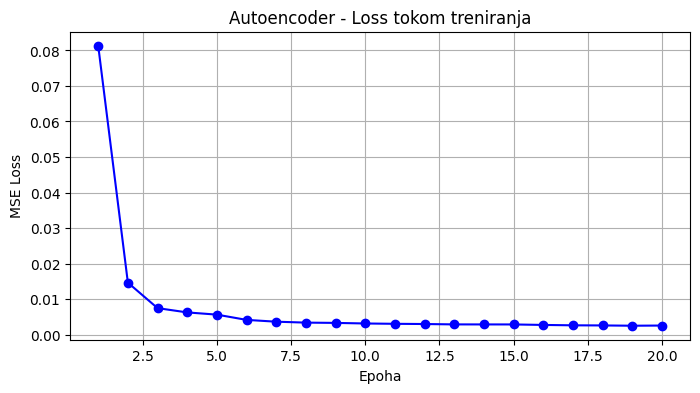

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, broj_epoha+1), loss_lista, marker='o', color='blue')
plt.title("Autoencoder - Loss tokom treniranja")
plt.xlabel("Epoha")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

### Evaluacija

In [12]:
model.eval()
greske = []
sve_labele = []

with torch.no_grad():
    for slike, labele in test_dataloader:
        slike = slike.to(uredjaj)
        rekonstrukcija = model(slike)
        greska = ((slike - rekonstrukcija) ** 2).mean(dim=[1, 2, 3])
        greske.extend(greska.cpu().numpy())
        sve_labele.extend(labele.numpy())

greske = np.array(greske)
sve_labele = np.array(sve_labele)

pragovi = np.linspace(greske.min(), greske.max(), 100)
najbolja_tacnost = 0
najbolji_prag = 0
for p in pragovi:
    pred = (greske > p).astype(int)
    if (pred == sve_labele).mean() > najbolja_tacnost:
        najbolja_tacnost = (pred == sve_labele).mean()
        najbolji_prag = p

predikcije = (greske > najbolji_prag).astype(int)

print(f"Optimalni prag: {najbolji_prag:.4f}")
print(f"Autoencoder tacnost: {najbolja_tacnost*100:.2f}%")
print(f"AUC-ROC: {roc_auc_score(sve_labele, greske):.4f}")

Optimalni prag: 0.0003
Autoencoder tacnost: 74.26%
AUC-ROC: 0.4884


### Vizualizacija rekonstrukcije

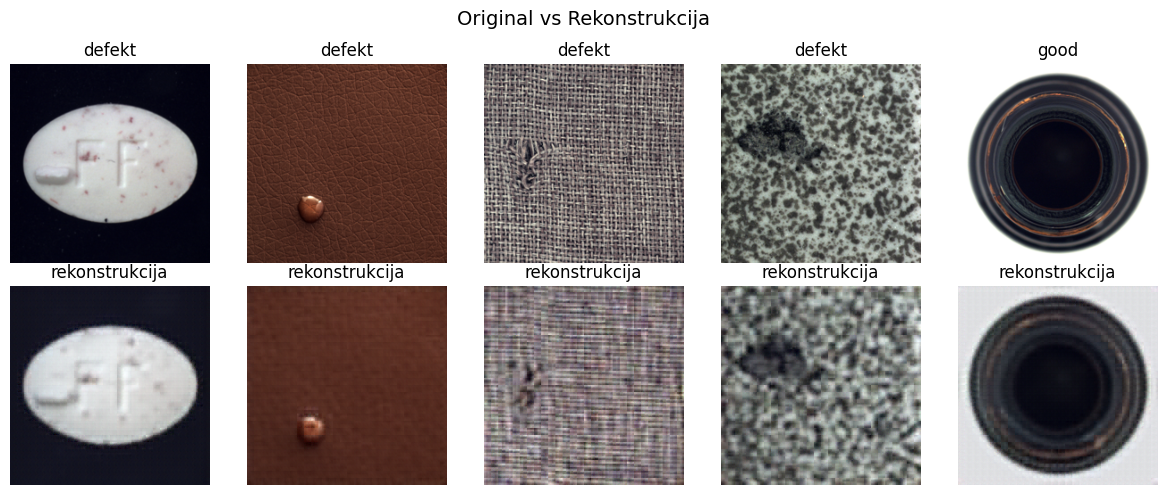

In [15]:
slike, labele = next(iter(test_dataloader))
slike = slike.to(uredjaj)

model.eval()
with torch.no_grad():
    rekonstrukcija = model(slike)

fig, ose = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Original vs Rekonstrukcija", fontsize=14)

for i in range(5):
    slika = slike[i].cpu().permute(1, 2, 0).numpy()
    slika = (slika - slika.min()) / (slika.max() - slika.min())

    ose[0, i].imshow(slika)
    ose[0, i].set_title(f"{'good' if labele[i]==0 else 'defekt'}")
    ose[0, i].axis("off")

    rek = rekonstrukcija[i].cpu().permute(1, 2, 0).numpy()
    rek = (rek - rek.min()) / (rek.max() - rek.min())

    ose[1, i].imshow(rek)
    ose[1, i].set_title(f"rekonstrukcija")
    ose[1, i].axis("off")

plt.tight_layout()
plt.show()

### Distribucija rekonstrukcione greske

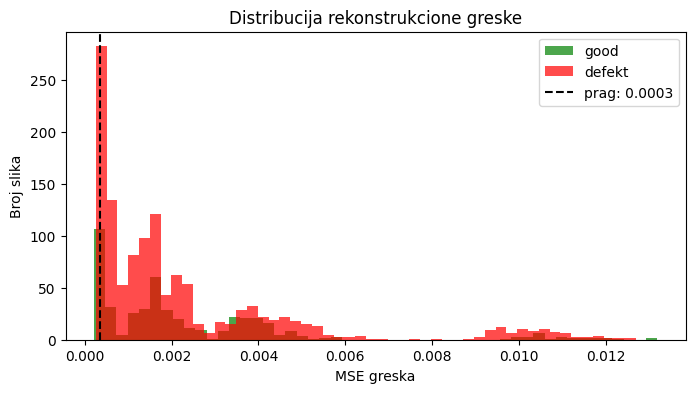

In [16]:
plt.figure(figsize=(8, 4))
plt.hist(greske[sve_labele == 0], bins=50, alpha=0.7, label='good', color='green')
plt.hist(greske[sve_labele == 1], bins=50, alpha=0.7, label='defekt', color='red')
plt.axvline(najbolji_prag, color='black', linestyle='--', label=f'prag: {najbolji_prag:.4f}')
plt.title("Distribucija rekonstrukcione greske")
plt.xlabel("MSE greska")
plt.ylabel("Broj slika")
plt.legend()
plt.show()